# Customer Segmentation Analysis using K-Means Clustering

Perbedaan karakteristik dan perilaku belanja pelanggan menjadi tantangan dalam penyusunan strategi pemasaran. Oleh karena itu, proyek ini menerapkan metode K-Means Clustering untuk mengelompokkan pelanggan berdasarkan kesamaan karakteristik guna menghasilkan rekomendasi bisnis yang mendukung strategi pemasaran yang lebih tepat sasaran.

------------------------------------------------------------------------------

**Author:** Evanda Nur Haliza

**Tools:** Python, Pandas, Scikit-Learn, Matplotlib, Seaborn

**Dataset:** Mall Customer Dataset (Kaggle)

**Project Type:** Data Analytics | Customer Segmentation

-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

## Table of Contents
1. [Business Understanding](#business-understanding)
2. [Data Understanding](#data-understanding)
3. [Data Cleaning](#data-cleaning)
4. [Exploratory Data Analysis](#eda)
5. [Feature Engineering](#feature-engineering)
6. [K-Means Clustering](#kmeans-clustering)
7. [Evaluation](#evaluation)
8. [Business Insight](#business-insight)
9. [Conclusion](#conclusion)

<a id="business-understanding"></a>

## 1. Business Understanding

### Business Background
Dalam dunia bisnis, setiap pelanggan memiliki karakteristik dan perilaku pembelian yang berbeda. Perbedaan tersebut dapat dipengaruhi oleh berbagai faktor, seperti usia, tingkat pendapatan, serta kebiasaan dalam melakukan pengeluaran. Oleh karena itu, menerapkan strategi pemasaran yang sama kepada seluruh pelanggan sering kali kurang efektif karena tidak mempertimbangkan kebutuhan dan karakteristik masing-masing kelompok pelanggan.

Studi kasus ini menggunakan Mall Customer Dataset yang bersumber dari kaggle sebagai simulasi  permasalahan bisnis retail, guna mendemonstrasikan penerapan customer segmentation dengan K-Means Clustering.

Pada kasus ini, perusahaan belum memiliki strategi pemasaran yang terarah karena seluruh pelanggan diperlakukan sebagai satu kelompok yang sama. Akibatnya, promosi yang diberikan berpotensi kurang tepat sasaran sehingga efektivitas pemasaran menjadi tidak optimal.

Salah satu pendekatan yang dapat digunakan untuk mengatasi permasalahan tersebut adalah melakukan customer segmentation, yaitu mengelompokkan pelanggan berdasarkan karakteristik yang dimiliki. Dengan mengetahui karakteristik setiap kelompok pelanggan, perusahaan dapat menyusun strategi pemasaran yang lebih selaras dengan kebutuhan tiap segmen, meningkatkan efektivitas promosi, serta memberikan penawaran yang lebih sesuai dengan perilaku masing-masing segmen pelanggan.


### Business Problem
Perusahaan belum memiliki segmentasi pelanggan yang jelas sehingga strategi pemasaran dan promosi masih diberikan secara umum kepada seluruh pelanggan. Tanpa segmentasi pelanggan, perusahaan kesulitan menentukan target promosi, mengalokasikan anggaran pemasaran secara efisien, serta menawarkan program yang sesuai dengan karakteristik masing-masing pelanggan.

### Project Objective
Project ini bertujuan untuk mengidentifikasi kelompok pelanggan berdasarkan karakteristik yang dimiliki menggunakan algoritma K-Means Clustering. Hasil segmentasi tersebut kemudian digunakan untuk memahami karakteristik setiap kelompok pelanggan serta menyusun rekomendasi strategi pemasaran yang lebih relevan bagi masing-masing segmen.

### Business Questions
1. Apakah pelanggan dapat dikelompokkan berdasarkan karakteristik yang dimiliki? 
2. Karakteristik apa yang membedakan setiap kelompok pelanggan? 
3. Segmen pelanggan mana yang memiliki potensi bisnis terbesar? 
4. Strategi pemasaran seperti apa yang paling sesuai untuk masing-masing kelompok pelanggan? 
5. Bagaimana hasil segmentasi pelanggan dapat membantu perusahaan dalam meningkatkan efektivitas kegiatan pemasaran?


### Success Criteria
Project ini dianggap berhasil apabila memenuhi kriteria berikut:
1. Pelanggan berhasil dikelompokkan ke dalam beberapa cluster yang memiliki karakteristik yang berbeda. 
2. Setiap cluster memiliki profil pelanggan yang jelas berdasarkan hasil analisis data. 
3. Diperoleh insight bisnis yang dapat digunakan untuk memahami perilaku setiap kelompok pelanggan. 
4. Dihasilkan rekomendasi strategi pemasaran yang sesuai untuk masing-masing segmen pelanggan sehingga dapat mendukung pengambilan keputusan bisnis.
5. Hasil clustering memiliki kualitas yang baik, ditunjukkan dengan nilai 
Silhouette Score minimal 0.5, serta menghasilkan jumlah cluster yang masuk 
akal secara bisnis (3–6 segmen) sehingga tetap dapat diinterpretasikan dan 
ditindaklanjuti sebagai strategi pemasaran.



### Scope & Limitation
Project ini menggunakan Mall Customer Dataset (Kaggle) yang terdiri atas 200 
data pelanggan dengan variabel Age, Annual Income, dan Spending Score. Proses 
segmentasi hanya menggunakan variabel Annual Income dan Spending Score, 
sehingga hasil cluster tidak mencerminkan seluruh aspek perilaku pelanggan 
secara nyata. Selain itu, dataset ini tidak mencakup data transaksi aktual, 
riwayat pembelian, maupun preferensi produk, sehingga rekomendasi strategi 
pemasaran yang dihasilkan bersifat ilustratif dan perlu divalidasi lebih 
lanjut dengan data riil sebelum diterapkan dalam pengambilan keputusan bisnis.

<a id="data-understanding"></a>

## 2. Data Understanding

Pada tahap ini dilakukan eksplorasi awal terhadap dataset untuk memahami struktur data, tipe data, jumlah observasi, serta karakteristik setiap variabel sebelum dilakukan proses data cleaning dan analisis lebih lanjut.

### 2.1 Data Dictionary

Sebelum melakukan eksplorasi data, penting untuk memahami terlebih dahulu 
makna setiap kolom yang terdapat pada dataset Mall Customer. Pemahaman ini 
membantu memastikan setiap variabel diinterpretasikan secara tepat sepanjang 
proses analisis dan clustering.

| Kolom | Tipe Data | Deskripsi |
|---|---|---|
| CustomerID | Numerik (int) | Nomor identitas unik untuk setiap pelanggan. Tidak digunakan dalam proses clustering karena tidak merepresentasikan karakteristik pelanggan. |
| Gender | Kategorikal (object) | Jenis kelamin pelanggan (Male/Female). Digunakan sebagai variabel deskriptif untuk memperkaya profil cluster, bukan sebagai fitur dalam proses clustering. |
| Age | Numerik (int) | Usia pelanggan dalam tahun. |
| Annual Income (k$) | Numerik (int) | Pendapatan tahunan pelanggan, dalam satuan ribuan dolar AS. |
| Spending Score (1-100) | Numerik (int) | Skor yang diberikan oleh pihak mall berdasarkan perilaku dan pola belanja pelanggan, dengan skala 1 (rendah) hingga 100 (tinggi). **Skor ini bukan merupakan nominal uang yang dibelanjakan**, melainkan indikator yang dihitung oleh mall untuk merepresentasikan tingkat keterlibatan

### Import Libraries

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.metrics import davies_bouldin_score

warnings.filterwarnings('ignore')

### 2.2 Load Dataset

Pada tahap ini dataset akan dimuat ke dalam Python menggunakan library pandas. Dataset kemudian disimpan ke dalam sebuah DataFrame agar dapat dilakukan proses eksplorasi, pembersihan data, dan analisis pada tahap berikutnya.

In [41]:
df = pd.read_csv("../data/Mall_Customers.csv")

In [42]:
df = df.rename(columns={'Annual Income (k$)': 'AnnualIncome', 'Spending Score (1-100)': 'SpendingScore'})

### 2.3 Dataset Preview

Pada tahap ini ditampilkan lima baris pertama dari dataset untuk memperoleh gambaran awal mengenai struktur data, nama kolom, serta memastikan dataset telah berhasil dimuat sebelum dilakukan analisis lebih lanjut.

In [43]:
df.head()

,CustomerID,Gender,Age,AnnualIncome,SpendingScore
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


### 2.4 Dataset Dimension

Pada tahap ini akan dilakukan identifikasi ukuran dataset untuk mengetahui jumlah baris (observasi) dan kolom (fitur) yang tersedia sebagai gambaran awal struktur data sebelum proses analisis lebih lanjut.

In [44]:
df.shape

(200, 5)

Berdasarkan hasil df.shape, dataset Mall Customers terdiri atas 200 baris dan 5 kolom. Hal ini menunjukkan bahwa terdapat 200 data pelanggan dengan lima kolom yang berisi informasi mengenai CustomerID, Gender, Age, Annual Income, dan Spending Score. Informasi mengenai ukuran dataset ini memberikan gambaran awal mengenai struktur data sebelum dilakukan proses eksplorasi, pembersihan data, dan pemilihan fitur yang akan digunakan pada tahap clustering.

### 2.5 Dataset Information

Pada tahap ini akan dilakukan identifikasi struktur dataset, meliputi nama setiap kolom, jumlah data non-null, tipe data, dan penggunaan memori. Informasi ini membantu memastikan dataset siap untuk tahap analisis selanjutnya.

In [45]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   CustomerID     200 non-null    int64 
 1   Gender         200 non-null    object
 2   Age            200 non-null    int64 
 3   AnnualIncome   200 non-null    int64 
 4   SpendingScore  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


Hasil df.info() menunjukkan bahwa dataset terdiri atas 200 baris dan 5 kolom. Seluruh kolom memiliki 200 nilai non-null sehingga tidak terdapat missing values pada dataset. Selain itu, tipe data setiap kolom telah sesuai, yaitu empat kolom bertipe int64 (CustomerID, Age, Annual Income (k$), dan Spending Score (1-100)) serta satu kolom bertipe object (Gender). Dengan demikian, tidak diperlukan perubahan tipe data sebelum proses analisis lebih lanjut.

### 2.6 CustomerID Uniqueness Check
Pada tahap ini dilakukan pengecekan terhadap kolom CustomerID untuk 
memastikan setiap pelanggan memiliki identitas yang unik, sehingga tidak 
terdapat pencatatan ganda yang dapat memengaruhi hasil analisis pada tahap 
selanjutnya.

In [46]:
df['CustomerID'].nunique()

200

Hasil pengecekan menunjukkan bahwa jumlah nilai unik pada kolom CustomerID 
adalah 200, sama dengan jumlah total baris pada dataset. Dengan demikian, 
setiap pelanggan memiliki identitas yang unik dan tidak terdapat duplikasi 
CustomerID pada dataset ini.

### 2.7 Statistical Summary

Pada tahap ini akan dilakukan analisis statistik deskriptif terhadap setiap fitur numerik pada dataset. Tujuannya adalah untuk memperoleh gambaran umum mengenai distribusi data, seperti nilai rata-rata, persebaran data, nilai minimum, kuartil, dan nilai maksimum sebelum dilakukan analisis lebih lanjut.

In [47]:
df.describe()

,CustomerID,Age,AnnualIncome,SpendingScore
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


Hasil df.describe() menunjukkan bahwa seluruh fitur numerik memiliki 200 
data, sehingga konsisten dengan jumlah observasi pada dataset. Rata-rata 
usia pelanggan adalah 38,85 tahun dengan median 36 tahun. Adanya sedikit selisih antara mean dan median ini mengindikasikan distribusi usia yang sedikit condong ke kanan (right-skewed), dengan sebagian pelanggan berusia lebih tua menarik nilai rata-rata ke atas.

Annual Income memiliki mean 60,56 ribu dolar dan median 61,50 ribu dolar 
yang saling berdekatan, mengindikasikan distribusi yang relatif simetris 
tanpa skew signifikan. Hal serupa terlihat pada Spending Score, dengan mean 
50,20 dan median 50,00 yang hampir identik, menunjukkan distribusi yang 
merata di sepanjang skala 1–100.

Dari sisi variabilitas, Annual Income (std 26,26) dan Spending Score 
(std 25,82) menunjukkan sebaran data yang cukup lebar dan proporsional 
terhadap rentang datanya, sementara Age (std 13,97) relatif lebih 
terkonsentrasi di sekitar rata-rata. Karakteristik distribusi ini 
mengonfirmasi bahwa Annual Income dan Spending Score memiliki variasi yang 
cukup untuk membentuk kelompok-kelompok pelanggan yang berbeda pada tahap 
clustering.

Pemahaman awal terhadap struktur dan karakteristik data ini menjadi dasar dalam menentukan fitur yang relevan untuk proses clustering pada tahap selanjutnya.

<a id="data-cleaning"></a>
## 3. Data Cleaning

### 3.1 Missing Values
Pada tahap ini dilakukan pengecekan missing values untuk memastikan tidak terdapat data yang hilang pada setiap kolom sebelum proses analisis dan clustering dilakukan.

In [48]:
df.isnull().sum()

CustomerID       0
Gender           0
Age              0
AnnualIncome     0
SpendingScore    0
dtype: int64

Hasil pengecekan menunjukkan bahwa seluruh kolom memiliki nilai missing value sebanyak 0. Dengan demikian, tidak terdapat data yang hilang pada dataset sehingga tidak diperlukan proses penanganan missing values sebelum dilakukan analisis lebih lanjut.

### 3.2 Duplicate Data

Pada tahap ini dilakukan pengecekan data duplikat untuk memastikan setiap data pelanggan bersifat unik dan tidak terdapat pencatatan yang berulang pada dataset.

In [49]:
df.duplicated().sum()

np.int64(0)

Hasil pengecekan menunjukkan bahwa tidak terdapat data duplikat pada dataset (0 duplicate rows). Hal ini menunjukkan bahwa setiap data pelanggan bersifat unik sehingga tidak diperlukan proses penghapusan data duplikat sebelum analisis lebih lanjut.

### 3.3 Inconsistent Values
Pada tahap ini dilakukan pengecekan nilai kategorikal untuk memastikan tidak terdapat penulisan data yang tidak konsisten pada setiap fitur kategorikal.

In [50]:
df["Gender"].value_counts()

Gender
Female    112
Male       88
Name: count, dtype: int64

Hasil pengecekan menunjukkan bahwa Gender terdiri atas dua kategori yang 
konsisten (Female: 112, Male: 88) tanpa penulisan ganda atau nilai tidak 
valid. Karena Gender merupakan satu-satunya fitur kategorikal pada dataset, 
tidak diperlukan pengecekan tambahan pada tahap ini.

### 3.4 Outlier Detection 
Pada tahap ini dilakukan pengecekan outlier pada variabel numerik (Age, 
AnnualIncome, dan SpendingScore) menggunakan boxplot. Pengecekan ini penting 
dilakukan sebelum proses clustering karena algoritma K-Means bekerja 
berdasarkan jarak antar titik data, sehingga keberadaan outlier berpotensi 
memengaruhi posisi centroid dan menghasilkan pembagian cluster yang kurang 
representatif.

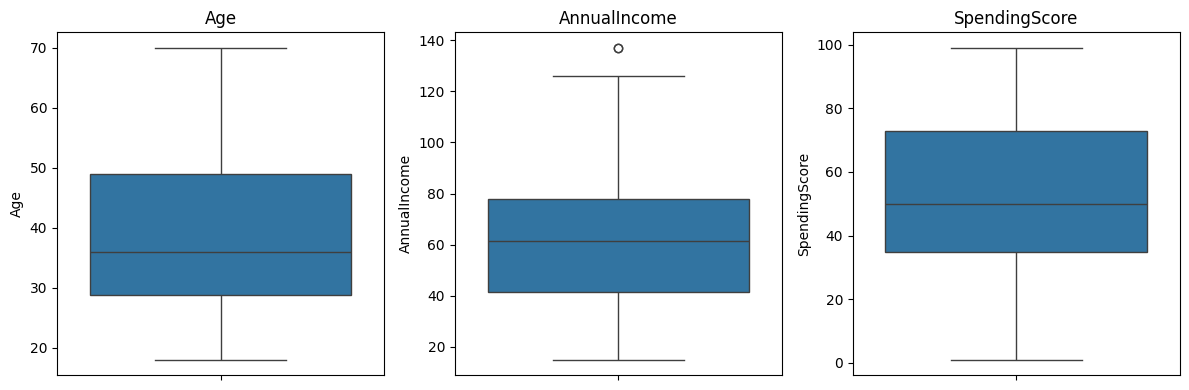

In [51]:
plt.figure(figsize=(12,4))
for i, col in enumerate(['Age', 'AnnualIncome', 'SpendingScore']):
    plt.subplot(1, 3, i+1)
    sns.boxplot(data=df, y=col)
    plt.title(col)
plt.tight_layout()
plt.show()

Hasil boxplot menunjukkan bahwa variabel Age dan SpendingScore tidak 
memiliki outlier, dengan seluruh data tersebar dalam rentang whisker yang 
wajar. Pada variabel AnnualIncome, terdeteksi satu titik outlier di sisi 
atas dengan nilai mendekati 140 ribu dolar. Namun, nilai tersebut masih 
berada dalam rentang pendapatan yang masuk akal secara bisnis dan 
kemungkinan besar merepresentasikan pelanggan dengan pendapatan tinggi, 
bukan kesalahan input data. Oleh karena itu, outlier ini tidak dihapus agar 
karakteristik pelanggan berpendapatan tinggi tetap dapat teridentifikasi 
pada tahap segmentasi.

### 3.5 Value Range Validation
Pada tahap ini dilakukan validasi terhadap rentang nilai setiap variabel 
numerik untuk memastikan tidak terdapat nilai yang tidak logis secara 
bisnis, seperti nilai negatif atau nilai di luar batas wajar.

In [52]:
print("Age range:", df['Age'].min(), "-", df['Age'].max())
print("AnnualIncome range:", df['AnnualIncome'].min(), "-", df['AnnualIncome'].max())
print("SpendingScore range:", df['SpendingScore'].min(), "-", df['SpendingScore'].max())

Age range: 18 - 70
AnnualIncome range: 15 - 137
SpendingScore range: 1 - 99


Berdasarkan hasil pengecekan, seluruh variabel numerik berada dalam rentang 
yang logis dan sesuai dengan definisi masing-masing kolom: Age berada pada 
rentang 18–70 tahun (rentang usia yang wajar), AnnualIncome berada pada 
rentang 15–137 ribu dolar (nilai positif, tidak ada pendapatan negatif), 
dan SpendingScore berada pada rentang 1–99 (sesuai dengan skala 1–100 yang 
ditetapkan). Dengan demikian, tidak ditemukan nilai yang tidak valid atau 
di luar batas wajar pada dataset ini, sehingga data dinyatakan siap untuk 
digunakan pada tahap analisis dan clustering selanjutnya.

## 4. Exploratory Data Analysis
Sebelum melakukan proses clustering, penting untuk memahami karakteristik pelanggan yang terdapat pada dataset. Tahap Exploratory Data Analysis (EDA) bertujuan untuk mengeksplorasi pola, distribusi, dan hubungan antar fitur sehingga proses pemilihan fitur serta interpretasi hasil clustering nantinya dapat dilakukan dengan lebih baik.

### 4.1. Customer Gender Distribution
**Business Question:** 
Apakah komposisi pelanggan didominasi oleh salah satu jenis kelamin?

#### Visualisasi

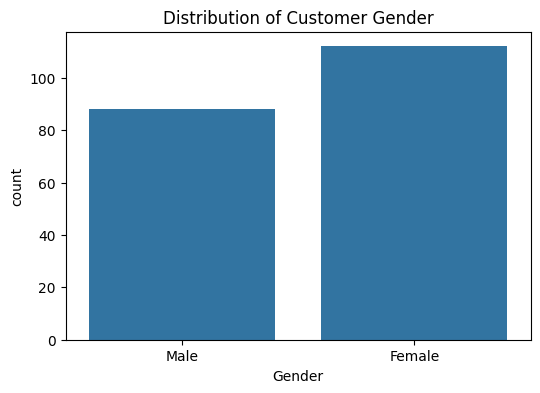

In [53]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Gender')
plt.title('Distribution of Customer Gender')
plt.show()


In [54]:

df['Gender'].value_counts(normalize=True) * 100

Gender
Female    56.0
Male      44.0
Name: proportion, dtype: float64

#### Data Insight
Visualisasi menunjukkan bahwa pelanggan perempuan (Female) berjumlah 112 
orang (56%), sedangkan pelanggan laki-laki (Male) berjumlah 88 orang (44%). 
Meskipun proporsi pelanggan perempuan sedikit lebih banyak, komposisi 
kedua kelompok masih tergolong seimbang (tidak timpang jauh), sehingga 
Gender tidak menunjukkan dominasi yang signifikan terhadap salah satu 
kelompok.

#### Business Interpretation
Meskipun fitur Gender tidak digunakan dalam proses K-Means karena bersifat kategorikal, informasi ini tetap bermanfaat untuk memberikan profil pada setiap cluster yang dihasilkan. Dengan demikian, hasil segmentasi nantinya dapat diinterpretasikan tidak hanya berdasarkan karakteristik numerik, tetapi juga berdasarkan komposisi jenis kelamin pelanggan.

### 4.2. Age Distribution
**Business Question:**
Bagaimana distribusi usia pelanggan pada dataset, dan apakah terdapat kelompok usia tertentu yang mendominasi?

#### Visualisasi

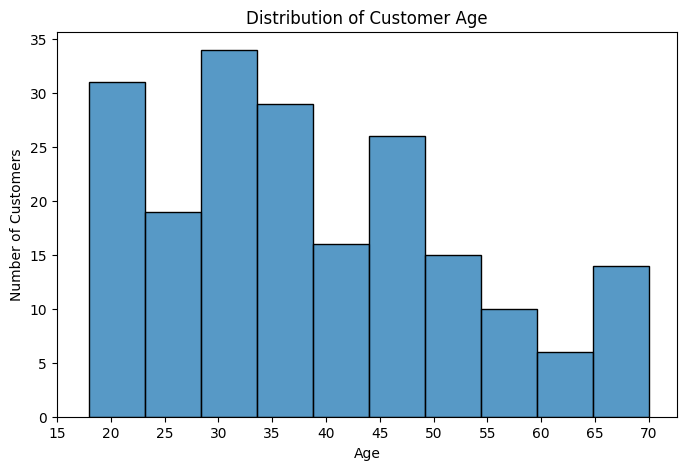

In [55]:
plt.figure(figsize=(8,5))
sns.histplot(data=df, x='Age', bins=10)
plt.title('Distribution of Customer Age')
plt.xticks(range(15, 71, 5))
plt.xlabel('Age')
plt.ylabel('Number of Customers')
plt.show()

#### Data Insight
Sebagian besar pelanggan berada pada rentang usia sekitar 20–45 tahun dan tidak terlihat indikasi outlier yang mencolok berdasarkan histogram.

#### Business Interpretation
Hal ini menunjukkan bahwa pelanggan didominasi oleh kelompok usia produktif. Oleh karena itu, fitur Age berpotensi menjadi salah satu variabel penting dalam proses segmentasi pelanggan menggunakan K-Means.

### 4.3. Annual Income Distribution
**Business Question:**
Bagaimana distribusi pendapatan tahunan pelanggan? Apakah terdapat kelompok pendapatan tertentu yang mendominasi?

#### Visualisasi

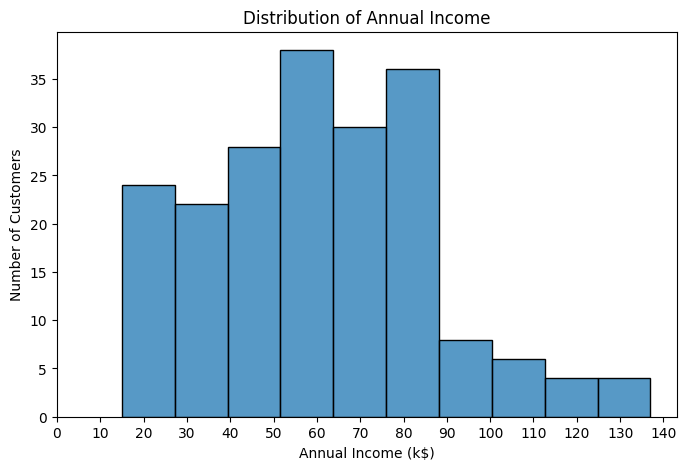

In [56]:
plt.figure(figsize=(8,5))

sns.histplot(data=df, x='AnnualIncome', bins=10)

plt.title('Distribution of Annual Income')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Number of Customers')

plt.xticks(range(0, 145, 10))

plt.show()

#### Data Insight
Distribusi Annual Income menunjukkan bahwa sebagian besar pelanggan memiliki pendapatan tahunan pada rentang menengah, dengan beberapa rentang pendapatan memiliki frekuensi yang lebih tinggi dibandingkan rentang lainnya. Berdasarkan histogram, belum dapat disimpulkan secara pasti keberadaan outlier sehingga analisis tersebut akan dilakukan menggunakan boxplot pada tahap selanjutnya.

#### Business Interpretation
Pendapatan tahunan merupakan salah satu karakteristik penting yang dapat memengaruhi daya beli pelanggan. Oleh karena itu, fitur Annual Income berpotensi menjadi variabel yang relevan dalam proses segmentasi pelanggan menggunakan algoritma K-Means.

### 4.4. Spending Score Distribution

**Business Question:** 
Bagaimana distribusi Spending Score pelanggan? Apakah pelanggan cenderung memiliki tingkat pengeluaran yang rendah, sedang, atau tinggi?

#### Visualisasi

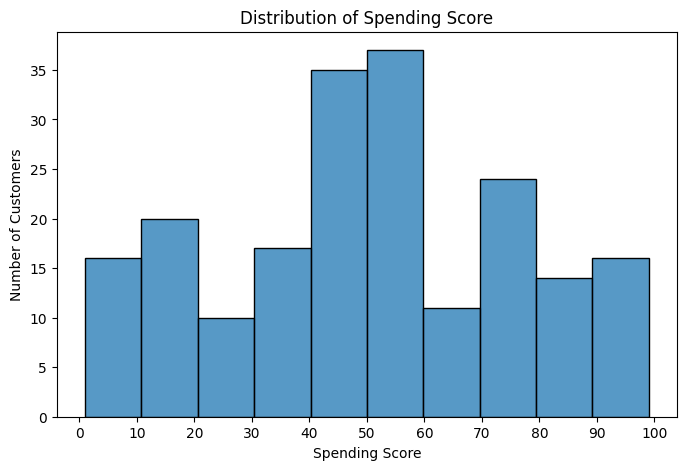

In [57]:
plt.figure(figsize=(8,5))

sns.histplot(data=df, x='SpendingScore', bins=10)

plt.title('Distribution of Spending Score')
plt.xlabel('Spending Score')
plt.ylabel('Number of Customers')

plt.xticks(range(0, 101, 10))

plt.show()

#### Data Insight
Distribusi Spending Score menunjukkan bahwa pelanggan memiliki tingkat pengeluaran yang bervariasi, mulai dari skor rendah hingga tinggi. Sebagian besar pelanggan berada pada rentang skor menengah, meskipun terdapat beberapa kelompok dengan frekuensi yang lebih tinggi dibandingkan rentang lainnya.

#### Business Interpretation
Spending Score merepresentasikan tingkat kecenderungan pelanggan dalam melakukan pembelian. Oleh karena itu, fitur ini sangat penting dalam proses segmentasi pelanggan karena dapat membedakan pelanggan yang aktif berbelanja dengan pelanggan yang cenderung jarang melakukan pembelian.

### 4.5. Relationship Between Numerical Features
Selain memahami karakteristik masing-masing fitur, penting juga untuk mengeksplorasi hubungan antar fitur numerik. Analisis ini bertujuan untuk mengidentifikasi pola yang dapat membantu memahami karakteristik pelanggan serta memberikan gambaran awal mengenai potensi segmentasi sebelum proses clustering dilakukan.

Sebelum membahas hubungan antar variabel satu per satu, ditampilkan 
terlebih dahulu correlation heatmap untuk memberikan gambaran menyeluruh 
mengenai kekuatan hubungan linear antar seluruh variabel numerik.

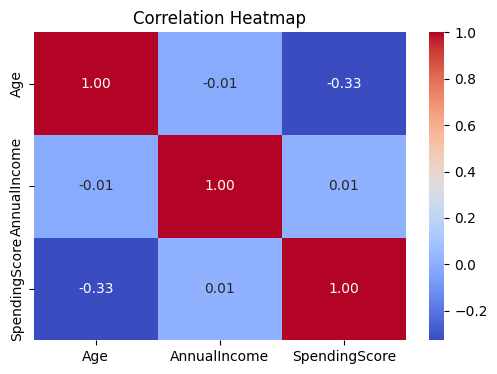

In [58]:
plt.figure(figsize=(6,4))
sns.heatmap(df[['Age', 'AnnualIncome', 'SpendingScore']].corr(), 
            annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

##### Data Insight
Heatmap menunjukkan bahwa seluruh pasangan variabel numerik memiliki 
korelasi linear yang lemah. Age dan SpendingScore memiliki korelasi negatif 
sebesar r = -0,33, tertinggi dibandingkan pasangan lainnya, sementara Age 
vs AnnualIncome (r = -0,01) dan AnnualIncome vs SpendingScore (r = 0,01) 
nyaris tidak menunjukkan korelasi sama sekali. Hasil ini menjadi dasar 
untuk mengeksplorasi masing-masing pasangan variabel secara lebih detail 
pada bagian berikut.

#### 4.5.1 Age vs Annual Income
**Business Question:** 
Apakah terdapat hubungan antara usia pelanggan dan pendapatan tahunan mereka?

##### Visualisasi

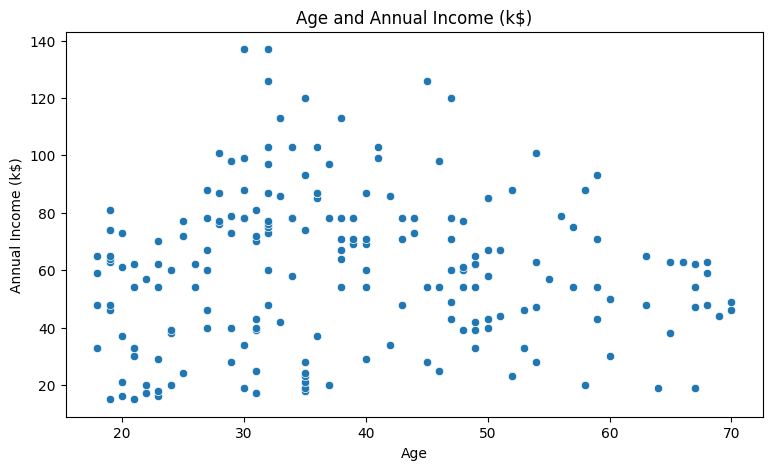

In [59]:
plt.figure(figsize=(9,5))
sns.scatterplot(data=df, x='Age', y='AnnualIncome')
plt.title('Age and Annual Income (k$)')
plt.xlabel('Age')
plt.ylabel('Annual Income (k$)')
plt.show()

##### Data Insight
Scatter plot menunjukkan bahwa tidak terdapat pola hubungan yang jelas 
antara usia pelanggan dan pendapatan tahunan, dengan koefisien korelasi 
sebesar r = -0,01. Nilai ini mengindikasikan hubungan yang sangat lemah 
antara kedua variabel, mendekati tidak ada korelasi sama sekali.

##### Business Interpretation
Berdasarkan hasil visualisasi, usia pelanggan tidak dapat digunakan sebagai indikator yang kuat untuk memperkirakan tingkat pendapatan. Oleh karena itu, hubungan antara kedua variabel ini kurang memberikan informasi yang signifikan dalam proses segmentasi pelanggan.

#### 4.5.2 Age vs Spending Score

**Business Question:** 
Apakah terdapat hubungan antara usia pelanggan dan tingkat pengeluaran (Spending Score) mereka?

##### Visualisasi

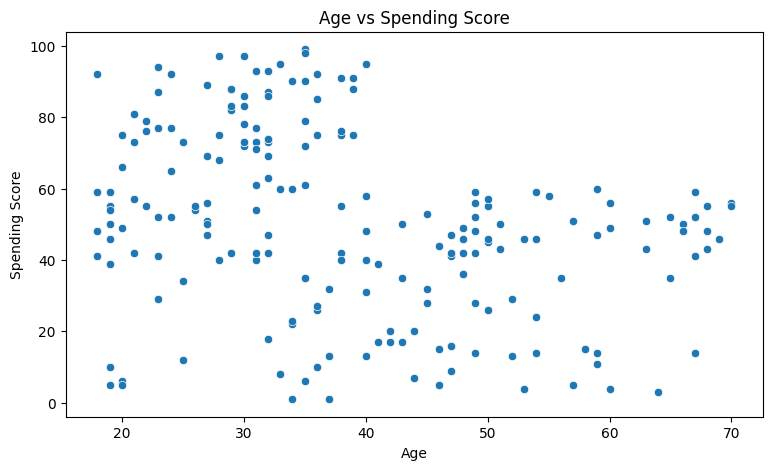

In [60]:
plt.figure(figsize=(9,5))
sns.scatterplot(data=df, x='Age', y='SpendingScore')
plt.title('Age vs Spending Score')
plt.xlabel('Age')
plt.ylabel('Spending Score')
plt.show()

##### Data Insight
Scatter plot menunjukkan bahwa hubungan antara usia dan Spending Score cenderung lemah, dengan koefisien korelasi sebesar r = -0,33. Pelanggan berusia muda memiliki variasi Spending Score yang lebih besar, sedangkan pelanggan berusia lebih tua cenderung memiliki Spending Score pada rentang yang lebih sempit. Namun, tidak terlihat pola hubungan yang konsisten antara kedua variabel tersebut.

##### Business Interpretation
Usia pelanggan belum dapat digunakan sebagai indikator utama dalam memperkirakan tingkat pengeluaran pelanggan. Oleh karena itu, hubungan antara kedua variabel ini kurang memberikan informasi yang kuat untuk mendukung proses segmentasi pelanggan.

#### 4.5.3 Annual Income vs Spending Score


**Business Question:** 
Apakah terdapat pola hubungan antara pendapatan tahunan dan Spending Score pelanggan yang dapat menjadi dasar segmentasi pelanggan?

##### Visualisasi

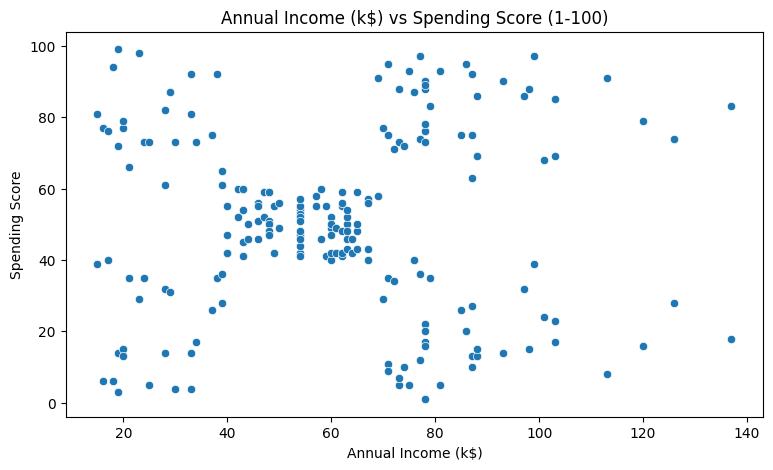

In [61]:
plt.figure(figsize=(9,5))
sns.scatterplot(data=df, x='AnnualIncome', y='SpendingScore')
plt.title('Annual Income (k$) vs Spending Score (1-100)')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score')
plt.show()

#### Data Insight
Scatter plot menunjukkan adanya beberapa kelompok pelanggan berdasarkan kombinasi pendapatan tahunan dan Spending Score, dengan koefisien korelasi sebesar r = 0,01. Meskipun korelasi linear tergolong lemah, pola 
non-linear (mengelompok) terlihat jelas secara visual, sehingga kombinasi 
kedua fitur ini tetap relevan untuk clustering meskipun tidak berkorelasi 
linear secara kuat.

##### Business Interpretation
Kombinasi Annual Income dan Spending Score memberikan informasi yang paling relevan untuk membedakan karakteristik pelanggan. Oleh karena itu, kedua fitur ini dipilih sebagai variabel utama dalam proses segmentasi pelanggan menggunakan algoritma K-Means.

### Ringkasan Exploratory Data Analysis
Berdasarkan hasil eksplorasi data pada Bab 4, diperoleh beberapa temuan 
utama sebagai berikut:

1. **Gender** memiliki komposisi yang relatif seimbang (56% Female, 44% 
Male) dan tidak digunakan sebagai fitur clustering karena bersifat 
kategorikal, namun tetap bermanfaat untuk memperkaya profil cluster.
2. **Age** didominasi oleh kelompok usia produktif (20–45 tahun), namun 
memiliki korelasi yang lemah terhadap AnnualIncome (r = -0,01) dan 
SpendingScore (r = -0,33), sehingga kurang relevan sebagai fitur utama 
clustering.
3. **AnnualIncome** dan **SpendingScore** menunjukkan korelasi linear yang 
sangat lemah (r = 0,01), namun secara visual memperlihatkan pola 
pengelompokan (non-linear) yang jelas pada scatter plot, menjadikan 
kombinasi keduanya sebagai kandidat fitur paling relevan untuk proses 
segmentasi.

Berdasarkan temuan tersebut, tahap selanjutnya (Feature Engineering) akan 
berfokus pada pemilihan dan persiapan fitur AnnualIncome dan SpendingScore 
sebagai dasar proses clustering menggunakan algoritma K-Means.

## 5. Feature Engineering
Sebelum membangun model clustering, perlu dilakukan proses feature engineering untuk menentukan fitur yang akan digunakan serta menyiapkan data agar sesuai dengan kebutuhan algoritma K-Means.

### 5.1 Feature Selection
**Business Question:** 
Fitur apa yang paling relevan digunakan untuk membentuk segmentasi pelanggan?

In [62]:
X = df[['AnnualIncome', 'SpendingScore']]
X.head()

,AnnualIncome,SpendingScore
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40


#### Data Insight
Berdasarkan hasil EDA, kombinasi **Annual Income** dan **Spending Score** dipilih sebagai fitur utama karena menunjukkan pola pengelompokan pelanggan yang paling jelas pada scatter plot. Sementara itu, fitur **Age** tidak menunjukkan pola yang cukup kuat untuk membedakan kelompok pelanggan, dan **Gender** tidak digunakan karena merupakan data kategorikal.

### 5.2 Feature Scaling
Sebelum proses clustering dilakukan, fitur perlu dinormalisasi terlebih 
dahulu. Hal ini penting karena AnnualIncome memiliki rentang 15–137 (ribu 
dolar), sedangkan SpendingScore berada pada rentang 1–99. Tanpa scaling, 
AnnualIncome berpotensi mendominasi perhitungan jarak Euclidean pada 
algoritma K-Means karena memiliki skala nilai yang jauh lebih besar, 
sehingga proses clustering dapat menjadi bias terhadap fitur tersebut. 
Pada tahap ini digunakan **StandardScaler**, yang mengubah data menjadi 
memiliki mean 0 dan standar deviasi 1, sehingga kedua fitur memiliki 
kontribusi yang seimbang dalam perhitungan jarak tanpa terpengaruh oleh 
perbedaan satuan maupun rentang nilai aslinya.

In [63]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [64]:
pd.DataFrame(X_scaled, columns=['AnnualIncome','SpendingScore']).describe()

,AnnualIncome,SpendingScore
count,2.000000e+02,2.000000e+02
mean,-2.131628e-16,-1.465494e-16
std,1.002509e+00,1.002509e+00
min,-1.738999e+00,-1.910021e+00
25%,-7.275093e-01,-5.997931e-01
50%,3.587926e-02,-7.764312e-03
75%,6.656748e-01,8.851316e-01
max,2.917671e+00,1.894492e+00


Hasil describe() pada data yang telah di-scaling menunjukkan bahwa mean 
kedua fitur mendekati 0 (dalam orde 10⁻¹⁶, dapat dianggap nol secara 
praktis) dan standar deviasi mendekati 1 (1,0025), mengonfirmasi bahwa 
proses scaling telah berhasil menyamakan skala kedua fitur. Selisih kecil 
dari nilai 1 tepat disebabkan oleh perbedaan formula perhitungan standar 
deviasi antara scikit-learn dan pandas, bukan indikasi kesalahan pada 
proses scaling.

Setelah proses seleksi dan scaling fitur selesai, data siap digunakan untuk membangun model K-Means Clustering pada tahap berikutnya.

## 6. K-Means Clustering
### 6.1 Determining the Optimal Number of Clusters

Sebelum menjalankan algoritma K-Means, perlu ditentukan jumlah cluster yang paling optimal. Pada tahap ini digunakan **Elbow Method** untuk mengevaluasi beberapa jumlah cluster sehingga dapat dipilih nilai *k* yang memberikan keseimbangan antara kualitas clustering dan kompleksitas model. 

**Business Question:** 
Berapa jumlah cluster yang paling optimal untuk merepresentasikan segmentasi pelanggan?

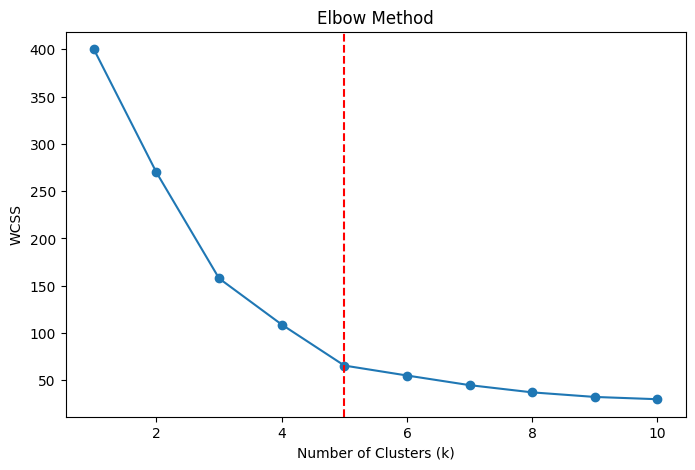

In [65]:
from sklearn.cluster import KMeans

wcss = []

for k in range(1, 11):
    kmeans_elbow = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans_elbow.fit(X_scaled)
    wcss.append(kmeans_elbow.inertia_)

plt.figure(figsize=(8, 5))

plt.plot(range(1, 11), wcss, marker='o')
plt.axvline(x=5, linestyle='--', color='red', label='Elbow Point (k=5)')

plt.title('Elbow Method')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('WCSS')

plt.savefig('../images/elbow_method.png', dpi=300, bbox_inches='tight')
plt.show()

#### Data Insight
Grafik Elbow Method menunjukkan bahwa nilai WCSS menurun secara tajam 
dari k=1 hingga k=5, kemudian penurunan mulai melandai secara signifikan 
setelah titik tersebut. Pola ini membentuk "siku" (elbow) pada k=5, yang 
mengindikasikan bahwa penambahan jumlah cluster lebih dari 5 tidak lagi 
memberikan pengurangan WCSS yang berarti. Oleh karena itu, k=5 dipilih 
sebagai jumlah cluster yang paling optimal, karena mampu menyeimbangkan 
antara kualitas pengelompokan (cluster yang cukup homogen) dan 
kompleksitas model (jumlah cluster yang masih mudah diinterpretasikan 
secara bisnis).

### 6.2 Build K-Means Model
Berdasarkan hasil Elbow Method, jumlah cluster optimal yang dipilih adalah lima. Pada tahap ini, model K-Means akan dibangun menggunakan data yang telah melalui proses standardisasi untuk mengelompokkan pelanggan berdasarkan kemiripan karakteristiknya. Parameter `random_state=42` 
digunakan agar hasil clustering dapat direproduksi secara konsisten pada 
setiap eksekusi, sedangkan `n_init=10` memastikan algoritma dijalankan 
sebanyak 10 kali dengan inisialisasi centroid yang berbeda-beda, sehingga 
model yang dipilih adalah hasil terbaik (WCSS terendah) dan terhindar dari 
local optima.

In [66]:
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
kmeans.fit(X_scaled)

KMeans(n_clusters=5, n_init=10, random_state=42)

### 6.3 Assign Cluster Labels
Setelah model K-Means berhasil dibangun, setiap pelanggan akan diberikan label cluster sesuai dengan hasil pengelompokan. Label ini akan digunakan pada tahap analisis untuk membandingkan karakteristik setiap cluster.

In [67]:
df['Cluster'] = kmeans.labels_
df.head()


,CustomerID,Gender,Age,AnnualIncome,SpendingScore,Cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,2
2,3,Female,20,16,6,4
3,4,Female,23,16,77,2
4,5,Female,31,17,40,4


### 6.4 Visualize Clusters
Untuk memudahkan interpretasi hasil clustering, dilakukan visualisasi menggunakan scatter plot berdasarkan fitur Annual Income dan Spending Score. Setiap warna merepresentasikan satu cluster pelanggan.

**Business Question:** Apakah hasil clustering menunjukkan pemisahan kelompok pelanggan yang jelas?

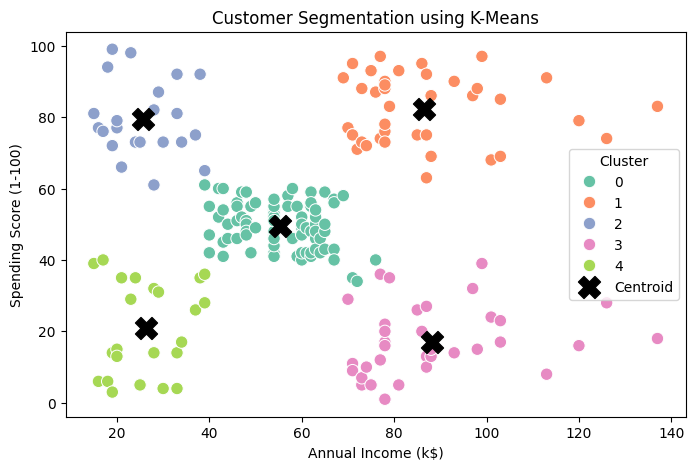

In [68]:
plt.figure(figsize=(8,5))

sns.scatterplot(data=df, x='AnnualIncome',y='SpendingScore', hue='Cluster', palette='Set2', s=80)

centers = scaler.inverse_transform(kmeans.cluster_centers_)
plt.scatter(centers[:, 0], centers[:, 1], s=250, c='black', marker='X', label='Centroid')

plt.title('Customer Segmentation using K-Means')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend(title='Cluster')

plt.savefig('../images/cluster_scatter.png', dpi=300, bbox_inches='tight')
plt.show()

##### Data Insight
Berdasarkan visualisasi hasil K-Means, pelanggan berhasil dikelompokkan ke dalam lima cluster yang memiliki karakteristik berbeda berdasarkan Annual Income dan Spending Score. Beberapa cluster tampak terpisah dengan cukup jelas, meskipun terdapat sedikit tumpang tindih pada beberapa area. Hasil ini menunjukkan bahwa kombinasi kedua fitur tersebut mampu membedakan perilaku pelanggan dan layak digunakan sebagai dasar segmentasi pelanggan.

## 7. Evaluation
Pada tahap ini dilakukan evaluasi terhadap hasil clustering menggunakan Silhouette Score. Metrik ini digunakan untuk mengukur seberapa baik setiap data ditempatkan pada clusternya dibandingkan dengan cluster lain.

### 7.1 Silhouette Score
Silhouette Score digunakan untuk mengevaluasi kualitas hasil clustering. Nilai metrik ini menunjukkan seberapa mirip suatu data dengan cluster tempatnya berada dibandingkan dengan cluster lain. Semakin mendekati 1, semakin baik kualitas pemisahan antar cluster.

In [69]:
silhouette = silhouette_score(X_scaled, kmeans.labels_)
davies_bouldin = davies_bouldin_score(X_scaled, kmeans.labels_)

print(f"Silhouette Score     : {silhouette:.3f}")
print(f"Davies-Bouldin Index : {davies_bouldin:.3f}")

Silhouette Score     : 0.555
Davies-Bouldin Index : 0.572


#### Data Insight Metrik Evaluasi

Silhouette Score sebesar 0.555 menunjukkan pemisahan antar cluster yang cukup baik, karena nilainya cukup jauh di atas 0 dan mendekati 1. Hasil ini didukung oleh Davies-Bouldin Index sebesar 0.572 yang berada di bawah 1, mengindikasikan tingkat kemiripan antar cluster yang rendah yang mana semakin kecil nilai metrik ini, semakin baik kualitas pemisahan cluster yang dihasilkan. Kedua metrik ini saling mendukung dan menunjukkan bahwa model clustering yang dibangun layak digunakan untuk segmentasi pelanggan.

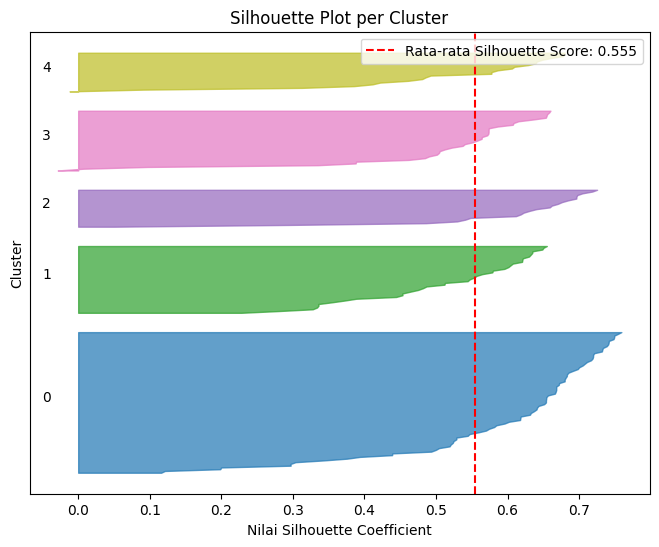

In [70]:
from sklearn.metrics import silhouette_samples
import matplotlib.cm as cm
import numpy as np

sample_silhouette_values = silhouette_samples(X_scaled, kmeans.labels_)
n_clusters = kmeans.n_clusters

fig, ax = plt.subplots(figsize=(8, 6))
y_lower = 10

for i in range(n_clusters):
    cluster_values = sample_silhouette_values[kmeans.labels_ == i]
    cluster_values.sort()

    size_cluster_i = cluster_values.shape[0]
    y_upper = y_lower + size_cluster_i

    color = cm.tab10(i / n_clusters)
    ax.fill_betweenx(
        np.arange(y_lower, y_upper),
        0, cluster_values,
        facecolor=color, edgecolor=color, alpha=0.7
    )

    ax.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))
    y_lower = y_upper + 10

ax.axvline(x=silhouette, color="red", linestyle="--", label=f"Rata-rata Silhouette Score: {silhouette:.3f}")
ax.set_title("Silhouette Plot per Cluster")
ax.set_xlabel("Nilai Silhouette Coefficient")
ax.set_ylabel("Cluster")
ax.set_yticks([])
ax.legend(loc="upper right")

plt.show()

In [71]:
sil_per_cluster = (
    pd.Series(sample_silhouette_values, index=df.index)
    .groupby(df['Cluster'])
    .mean()
    .round(3)
)
print(sil_per_cluster)

Cluster
0    0.598
1    0.511
2    0.598
3    0.505
4    0.511
dtype: float64


#### Data Insight — Silhouette Plot per Cluster

Berdasarkan silhouette plot dan rata-rata skor per cluster, terlihat bahwa Cluster 0, 1, 2, dan 3 memiliki nilai silhouette yang sebagian besar berada di sisi kanan garis merah (rata-rata skor), menandakan sampel-sampel tersebut sudah ditempatkan pada cluster yang tepat. Cluster 3 memiliki rata-rata silhouette paling rendah yaitu 0,505, namun nilai ini masih berada pada rentang positif sehingga tidak mengindikasikan kesalahan penempatan cluster yang signifikan. Secara keseluruhan, visualisasi silhouette plot mendukung hasil metrik evaluasi yang menunjukkan kualitas clustering yang baik.

### 7.2 Cluster Distribution
Pada tahap ini akan dianalisis jumlah pelanggan pada setiap cluster yang terbentuk. Distribusi cluster membantu mengetahui apakah hasil clustering menghasilkan pembagian pelanggan yang seimbang atau terdapat cluster yang mendominasi.

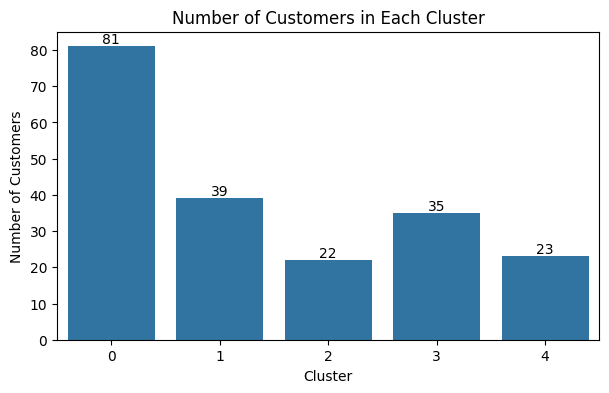

In [72]:
plt.figure(figsize=(7,4))

ax = sns.countplot(data=df, x='Cluster')
for container in ax.containers:
    ax.bar_label(container)

plt.title('Number of Customers in Each Cluster')
plt.xlabel('Cluster')
plt.ylabel('Number of Customers')

plt.savefig('../images/cluster_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

##### Data Insight

 Berdasarkan hasil distribusi cluster, dapat diketahui bahwa Cluster 0 memiliki jumlah pelanggan terbanyak, yaitu 81 pelanggan, sedangkan Cluster 2 merupakan kelompok dengan jumlah pelanggan paling sedikit, yaitu 22 pelanggan. Hal ini menunjukkan bahwa distribusi pelanggan pada setiap cluster tidak sepenuhnya seimbang.

##### Business Interpretation

Perbedaan jumlah pelanggan antar cluster masih tergolong wajar pada algoritma K-Means. Hal tersebut mengindikasikan bahwa karakteristik pelanggan dalam dataset memang tidak tersebar secara merata. Adanya cluster yang lebih besar menunjukkan terdapat segmen pelanggan dengan karakteristik yang lebih umum, sedangkan cluster yang lebih kecil merepresentasikan segmen pelanggan yang lebih spesifik sehingga memerlukan strategi pemasaran yang lebih terarah.

### 7.3 Cluster Profiling
Hasil clustering tidak hanya menunjukkan pembagian pelanggan ke dalam beberapa kelompok, tetapi juga perlu diinterpretasikan agar setiap cluster memiliki makna bisnis yang jelas. Oleh karena itu, pada tahap ini dilakukan cluster profiling, yaitu proses menganalisis karakteristik masing-masing cluster berdasarkan rata-rata usia (Age), pendapatan tahunan (Annual Income), skor pengeluaran (Spending Score), serta jumlah pelanggan pada setiap kelompok. Melalui proses ini, setiap cluster dapat dipahami secara lebih mendalam sehingga hasil segmentasi tidak hanya berupa label numerik, tetapi juga dapat menjadi dasar dalam penyusunan strategi pemasaran yang lebih tepat sasaran.

In [73]:
def build_cluster_summary(df, cluster_labels=None):
    summary = (
        df.groupby('Cluster')
        .agg({
            'Age': 'mean',
            'AnnualIncome': 'mean',
            'SpendingScore': 'mean'
        })
        .round(2)
        .rename(columns={
            'Age': 'Average Age',
            'AnnualIncome': 'Average Annual Income',
            'SpendingScore': 'Average Spending Score'
        })
    )
    summary.insert(0, 'Number of Customers', df['Cluster'].value_counts().sort_index())

    if cluster_labels is not None:
        summary.insert(0, 'Customer Segment', summary.index.map(cluster_labels))

    return summary

cluster_summary = build_cluster_summary(df)
cluster_summary

,Number of Customers,Average Age,Average Annual Income,Average Spending Score
Cluster,,,,
0,81,42.72,55.30,49.52
1,39,32.69,86.54,82.13
2,22,25.27,25.73,79.36
3,35,41.11,88.20,17.11
4,23,45.22,26.30,20.91


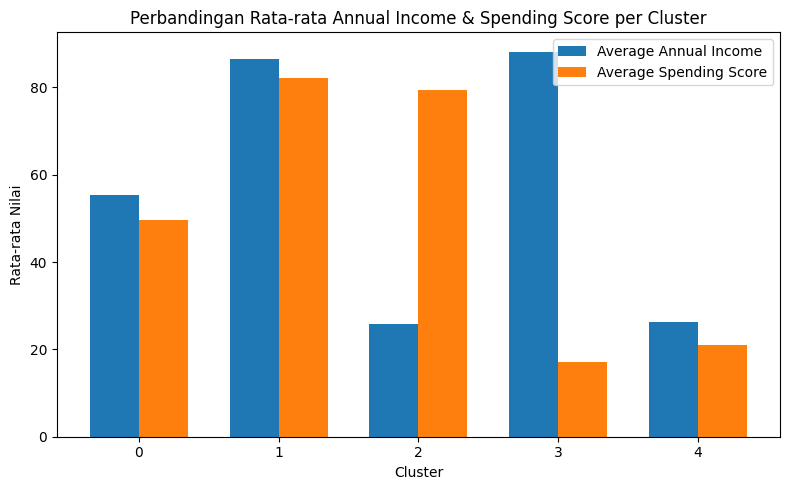

In [74]:
fig, ax = plt.subplots(figsize=(8, 5))

x = cluster_summary.index.astype(str)
width = 0.35
positions = range(len(x))

ax.bar([p - width/2 for p in positions], cluster_summary['Average Annual Income'],
       width=width, label='Average Annual Income')
ax.bar([p + width/2 for p in positions], cluster_summary['Average Spending Score'],
       width=width, label='Average Spending Score')

ax.set_xticks(list(positions))
ax.set_xticklabels(x)
ax.set_xlabel('Cluster')
ax.set_ylabel('Rata-rata Nilai')
ax.set_title('Perbandingan Rata-rata Annual Income & Spending Score per Cluster')
ax.legend()

plt.tight_layout()
plt.savefig('../images/cluster_profiling.png', dpi=300, bbox_inches='tight')
plt.show()

##### Data Insight
Berdasarkan hasil cluster profiling, terlihat bahwa setiap cluster memiliki karakteristik pelanggan yang berbeda dari segi usia (Age), pendapatan tahunan (Annual Income), dan tingkat pengeluaran (Spending Score). Perbedaan tersebut menunjukkan bahwa proses clustering berhasil mengelompokkan pelanggan dengan karakteristik yang relatif homogen di dalam masing-masing cluster.

Cluster 1 memiliki rata-rata Annual Income dan Spending Score tertinggi, yang mengindikasikan adanya kelompok pelanggan dengan daya beli dan aktivitas belanja yang tinggi. Sebaliknya, Cluster 3 memiliki pendapatan tinggi tetapi tingkat pengeluaran paling rendah, sehingga menunjukkan karakteristik pelanggan yang cenderung lebih selektif dalam berbelanja.

Selain itu, Cluster 2 didominasi oleh pelanggan dengan pendapatan relatif rendah namun memiliki Spending Score yang tinggi. Hal ini menunjukkan bahwa tingginya aktivitas belanja tidak selalu berkaitan dengan tingkat pendapatan. Sementara itu, Cluster 4 memiliki pendapatan dan tingkat pengeluaran yang sama-sama rendah, sedangkan Cluster 0 merupakan kelompok pelanggan terbesar dengan karakteristik yang relatif berada pada tingkat sedang untuk seluruh variabel.

### 7.4 Cluster Labeling
Setelah karakteristik masing-masing cluster berhasil diidentifikasi, langkah berikutnya adalah memberikan label yang merepresentasikan karakteristik utama setiap kelompok pelanggan. Pemberian label bertujuan untuk memudahkan interpretasi hasil clustering, sehingga setiap cluster tidak lagi hanya berupa angka, tetapi memiliki makna bisnis yang lebih jelas. Label ini disusun berdasarkan kombinasi rata-rata usia, pendapatan tahunan, dan tingkat pengeluaran yang dimiliki oleh setiap cluster.

In [75]:
cluster_labels = {
    0: 'Pelanggan Reguler',
    1: 'Pelanggan Premium',
    2: 'Pelanggan Aspirasional',
    3: 'Pelanggan Konservatif',
    4: 'Pelanggan Hemat'
}

df['Segmen Pelanggan'] = df['Cluster'].map(cluster_labels)

cluster_summary = build_cluster_summary(df, cluster_labels)
cluster_summary

,Customer Segment,Number of Customers,Average Age,Average Annual Income,Average Spending Score
Cluster,,,,,
0,Pelanggan Reguler,81,42.72,55.30,49.52
1,Pelanggan Premium,39,32.69,86.54,82.13
2,Pelanggan Aspirasional,22,25.27,25.73,79.36
3,Pelanggan Konservatif,35,41.11,88.20,17.11
4,Pelanggan Hemat,23,45.22,26.30,20.91


##### Data Insight
Berdasarkan karakteristik yang diperoleh pada tahap cluster profiling, setiap cluster diberikan label yang merepresentasikan karakteristik utama pelanggan. Pemberian label bertujuan untuk mempermudah interpretasi hasil clustering sehingga setiap kelompok pelanggan lebih mudah dipahami oleh stakeholder dibandingkan hanya menggunakan nomor cluster. Dengan demikian, hasil segmentasi menjadi lebih komunikatif dan dapat dijadikan dasar dalam penyusunan strategi bisnis yang sesuai untuk setiap kelompok pelanggan.

### 7.5 Business Insight per Cluster
Setelah setiap cluster diberikan label, langkah selanjutnya adalah menganalisis karakteristik bisnis dari masing-masing segmen pelanggan. Analisis ini bertujuan untuk memahami perilaku setiap kelompok pelanggan berdasarkan usia, pendapatan tahunan, dan tingkat pengeluaran sehingga perusahaan dapat mengenali potensi maupun karakteristik utama dari setiap segmen. Hasil analisis ini akan menjadi dasar dalam penyusunan rekomendasi strategi bisnis pada tahap berikutnya.

#### Cluster 0 - Pelanggan Reguler

**Karakteristik:**
- Memiliki jumlah pelanggan terbanyak.
- Rata-rata pendapatan dan Spending Score berada pada tingkat sedang.
- Didominasi oleh pelanggan usia dewasa.

**Insight Bisnis:**

Segmen ini merepresentasikan pelanggan dengan pola konsumsi yang relatif seimbang. Mereka memiliki kemampuan belanja yang sesuai dengan tingkat pendapatannya dan menunjukkan aktivitas pembelian yang stabil. Karena merupakan segmen dengan jumlah pelanggan terbesar, kelompok ini memiliki kontribusi yang penting terhadap keberlangsungan penjualan perusahaan meskipun nilai transaksi per pelanggan tidak setinggi segmen premium.

#### Cluster 1 - Pelanggan Premium

**Karakteristik:**
- Pendapatan tahunan tertinggi.
- Spending Score tertinggi.
- Didominasi pelanggan usia produktif.

**Insight Bisnis:**

Segmen ini terdiri atas pelanggan dengan daya beli dan aktivitas belanja yang sama-sama tinggi. Karakteristik tersebut menunjukkan bahwa kelompok ini memiliki potensi nilai pelanggan (customer value) yang besar sehingga berpotensi memberikan kontribusi pendapatan yang signifikan bagi perusahaan. Mempertahankan loyalitas pelanggan pada segmen ini menjadi hal yang penting karena kehilangan sebagian kecil pelanggan premium dapat memberikan dampak yang cukup besar terhadap penjualan.

#### Cluster 2 - Pelanggan Aspirasional

**Karakteristik:**
- Usia rata-rata paling muda.
- Pendapatan relatif rendah.
- Spending Score tinggi.

**Insight Bisnis:**

Meskipun memiliki tingkat pendapatan yang relatif rendah, pelanggan pada segmen ini menunjukkan aktivitas belanja yang tinggi. Hal ini mengindikasikan bahwa mereka tetap aktif melakukan pembelian dan memiliki minat yang tinggi terhadap produk yang ditawarkan. Karakteristik tersebut menjadikan segmen ini sebagai kelompok pelanggan yang memiliki potensi untuk terus berkembang seiring dengan peningkatan daya beli mereka di masa depan.

#### Cluster 3 - Pelanggan Konservatif

**Karakteristik:**
- Pendapatan tinggi.
- Spending Score paling rendah.
- Usia dewasa.

**Insight Bisnis:**

Segmen ini memiliki kemampuan finansial yang tinggi, namun menunjukkan kecenderungan untuk berbelanja secara lebih selektif dibandingkan segmen lainnya. Kondisi tersebut menunjukkan bahwa tingginya pendapatan tidak selalu diikuti dengan tingginya aktivitas pembelian. Oleh karena itu, kelompok ini memiliki potensi untuk ditingkatkan nilai transaksinya melalui pendekatan pemasaran yang lebih personal dan relevan dengan kebutuhan mereka.

#### Cluster 4 - Pelanggan Hemat

**Karakteristik:**
- Pendapatan rendah.
- Spending Score rendah.
- Usia relatif lebih dewasa.

**Insight Bisnis:**

Pelanggan pada segmen ini memiliki tingkat pendapatan dan aktivitas belanja yang sama-sama rendah. Karakteristik tersebut menunjukkan bahwa mereka cenderung lebih berhati-hati dalam melakukan pembelian. Meskipun kontribusi transaksi dari kelompok ini relatif kecil, segmen ini tetap berpotensi dipertahankan melalui penawaran produk yang sesuai dengan kebutuhan serta tingkat daya beli mereka.

## 8. Strategic Recommendation

Setelah setiap segmen pelanggan diprofilkan secara deskriptif pada Bab 7.5, tahap ini bertujuan menerjemahkan karakteristik tersebut menjadi rekomendasi strategis yang terukur. Berbeda dengan Bab 7.5 yang menjawab *"siapa mereka"*, bab ini berfokus menjawab tiga Business Questions yang telah ditetapkan pada Bab 1: 
(1) Apakah pelanggan dapat dikelompokkan?
(2) Karakteristik apa yang membedakan tiap kelompok?
(3) Segmen mana yang paling potensial untuk difokuskan dalam strategi pemasaran.

Untuk menjawab pertanyaan ketiga secara objektif pada tahap ini dihitung sebuah **Value Contribution Index**, yaitu proksi kontribusi nilai belanja tiap segmen yang mempertimbangkan jumlah pelanggan, rata-rata pendapatan, dan rata-rata Spending Score sekaligus. Pendekatan ini penting karena pendapatan tinggi saja tidak cukup untuk menyimpulkan segmen mana yang paling bernilai bagi bisnis serti perlu dilihat seberapa besar pendapatan tersebut benar-benar terkonversi menjadi aktivitas belanja.

In [76]:
cluster_summary['Value Contribution Index'] = (
    cluster_summary['Number of Customers'] *
    cluster_summary['Average Annual Income'] *
    (cluster_summary['Average Spending Score'] / 100)
)

cluster_summary['Value Contribution (%)'] = (
    cluster_summary['Value Contribution Index'] /
    cluster_summary['Value Contribution Index'].sum() * 100
).round(1)

cluster_summary.sort_values('Value Contribution (%)', ascending=False)

,Customer Segment,Number of Customers,Average Age,Average Annual Income,Average Spending Score,Value Contribution Index,Value Contribution (%)
Cluster,,,,,,,
1,Pelanggan Premium,39,32.69,86.54,82.13,2771.936778,45.5
0,Pelanggan Reguler,81,42.72,55.30,49.52,2218.149360,36.4
3,Pelanggan Konservatif,35,41.11,88.20,17.11,528.185700,8.7
2,Pelanggan Aspirasional,22,25.27,25.73,79.36,449.225216,7.4
4,Pelanggan Hemat,23,45.22,26.30,20.91,126.484590,2.1


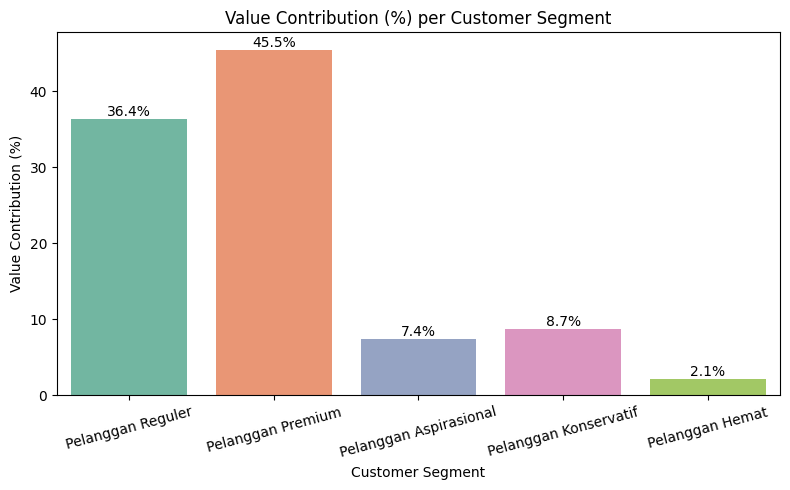

In [77]:
plt.figure(figsize=(8,5))

ax = sns.barplot(data=cluster_summary.reset_index(), 
                  x='Customer Segment', y='Value Contribution (%)', 
                  palette='Set2')
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%')

plt.title('Value Contribution (%) per Customer Segment')
plt.xlabel('Customer Segment')
plt.ylabel('Value Contribution (%)')
plt.xticks(rotation=15)
plt.tight_layout()

plt.savefig('../images/value_contribution.png', dpi=300, bbox_inches='tight')
plt.show()

#### Data Insight

Meskipun hanya berjumlah 39 pelanggan (19,5% dari total), **Premium Customers menyumbang kontribusi nilai belanja terbesar (45,5%)** yang melebihi Regular Customers yang jumlahnya lebih dari dua kali lipat. Bersama-sama, kedua segmen ini (Premium + Regular) merepresentasikan 60% dari total pelanggan namun menyumbang lebih dari 80% estimasi kontribusi nilai belanja, sehingga menjadi prioritas utama alokasi sumber daya pemasaran.

Temuan yang menarik terdapat pada **Conservative Customers**: meskipun memiliki rata-rata pendapatan tertinggi kedua (88,20), kontribusi nilainya hanya 8,7% — hampir setara dengan Aspirational Customers yang pendapatannya jauh lebih rendah (25,73). Hal ini menegaskan insight dari Bab 7: **pendapatan tinggi tidak otomatis berarti nilai bisnis tinggi** apabila tidak diikuti aktivitas belanja yang sepadan. Justru di sinilah letak peluang Conservative Customers merupakan segmen dengan *untapped potential* terbesar karena daya beli mereka belum tergarap optimal.

| Priority | Customer Segment | Business Objective | Key Recommendation | Success Metric |
|:---|:---|:---|:---|:---|
| **High** | Premium Customers | Mempertahankan loyalitas pelanggan bernilai tertinggi. | Membership eksklusif, layanan personal, early access produk baru. | Customer retention rate, repeat purchase rate |
| **High** | Regular Customers | Meningkatkan frekuensi & nilai transaksi. | Program loyalitas berjenjang, bundling produk, promosi personal. | Average transaction value, purchase frequency |
| **Medium** | Conservative Customers | Mengonversi daya beli tinggi menjadi aktivitas belanja. | Personalized offer berbasis preferensi, komunikasi 1-on-1 (relationship marketing). | Spending Score movement, conversion rate dari offer |
| **Medium** | Aspirational Customers | Mempertahankan keterlibatan & mendorong pertumbuhan daya beli. | Promo berkala, cicilan/produk terjangkau, program loyalitas berbasis poin. | Engagement rate, repeat visit rate |
| **Low** | Budget-Conscious Customers | Mempertahankan pelanggan dengan efisiensi biaya pemasaran. | Produk ekonomis, promosi massal (bukan personal, karena ROI rendah). | Retention rate dengan biaya marketing minimal |

#### Kesimpulan Strategis

Berdasarkan hasil analisis pada Bab 6-8, ketiga Business Questions yang ditetapkan pada Bab 1 dapat dijawab sebagai berikut:

1. **Apakah pelanggan dapat dikelompokkan berdasarkan karakteristiknya?** Ya — algoritma K-Means berhasil membentuk 5 segmen dengan pemisahan yang cukup baik (Silhouette Score 0.555).
2. **Karakteristik apa yang membedakan setiap kelompok?** Kombinasi Annual Income dan Spending Score, dengan pola yang tidak selalu linear — pendapatan tinggi tidak menjamin Spending Score tinggi (lihat Conservative Customers).
3. **Segmen mana yang paling potensial?** Premium dan Regular Customers adalah prioritas utama karena menyumbang lebih dari 80% estimasi kontribusi nilai belanja meski hanya 60% dari total pelanggan. Conservative Customers menjadi target sekunder dengan potensi pertumbuhan nilai tertinggi bila strategi konversi berhasil diterapkan.

## 9. Conclusion

Proyek ini menerapkan algoritma K-Means Clustering untuk mengelompokkan 200 pelanggan Mall Customer Dataset ke dalam lima segmen berdasarkan Annual Income dan Spending Score. Bagian ini merangkum hasil analisis, mengevaluasi pencapaian terhadap Success Criteria yang ditetapkan pada Bab 1, serta menyampaikan keterbatasan dan arah pengembangan selanjutnya.

### Pencapaian terhadap Success Criteria

| Success Criteria (Bab 1) | Status | Bukti |
|:---|:---|:---|
| Pelanggan berhasil dikelompokkan ke dalam cluster dengan karakteristik berbeda | ✅ Tercapai | 5 cluster terbentuk dengan Silhouette Score 0.555, menunjukkan pemisahan antar-cluster cukup baik |
| Setiap segmen memiliki profil yang dapat diinterpretasikan secara bisnis | ✅ Tercapai | Setiap cluster berhasil diberi label & business insight (Bab 7.5) yang konsisten dengan pola data |
| Hasil dapat menjadi dasar rekomendasi strategi pemasaran | ✅ Tercapai | Rekomendasi strategis dengan prioritas terukur telah disusun pada Bab 8 |

### Future Work

- Menambahkan variabel perilaku transaksi riil (frekuensi pembelian, recency, kategori produk denganpendekatan RFM) untuk memperkaya profil segmen di luar data demografis.
- Membandingkan performa K-Means dengan algoritma clustering lain (Hierarchical, DBSCAN, Gaussian Mixture Model) untuk menguji kestabilan segmentasi.
- Melakukan validasi periodik (misalnya re-run clustering tiap kuartal) untuk memastikan segmen tetap relevan seiring perubahan perilaku pelanggan.
- Mengintegrasikan model ke dalam pipeline sederhana yang dapat memprediksi cluster pelanggan baru secara otomatis, sebagai dasar sistem rekomendasi pemasaran yang lebih dinamis.

### Penutup

Secara keseluruhan, penerapan K-Means Clustering pada Mall Customer Dataset berhasil menghasilkan segmentasi pelanggan yang bermakna secara bisnis dan menjawab seluruh Business Questions yang ditetapkan pada Bab 1. Hasil ini memberikan dasar kuantitatif bagi perusahaan untuk memprioritaskan alokasi sumber daya pemasaran, alih-alih menerapkan strategi yang sama untuk seluruh pelanggan sekaligus mengidentifikasi segmen dengan potensi pertumbuhan nilai yang belum tergarap optimal, seperti Conservative Customers. Dengan mempertimbangkan keterbatasan yang telah diuraikan, hasil analisis ini paling tepat digunakan sebagai *starting point* strategi segmentasi, yang perlu terus divalidasi seiring bertambahnya data dan waktu.